In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft  # for fast fourier transform
from scipy.fftpack import dct # for discrete cosine transform
import librosa # for audio processing
import librosa.display  # for visualizing audio data

# Plot settings
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

(16000,)
16000


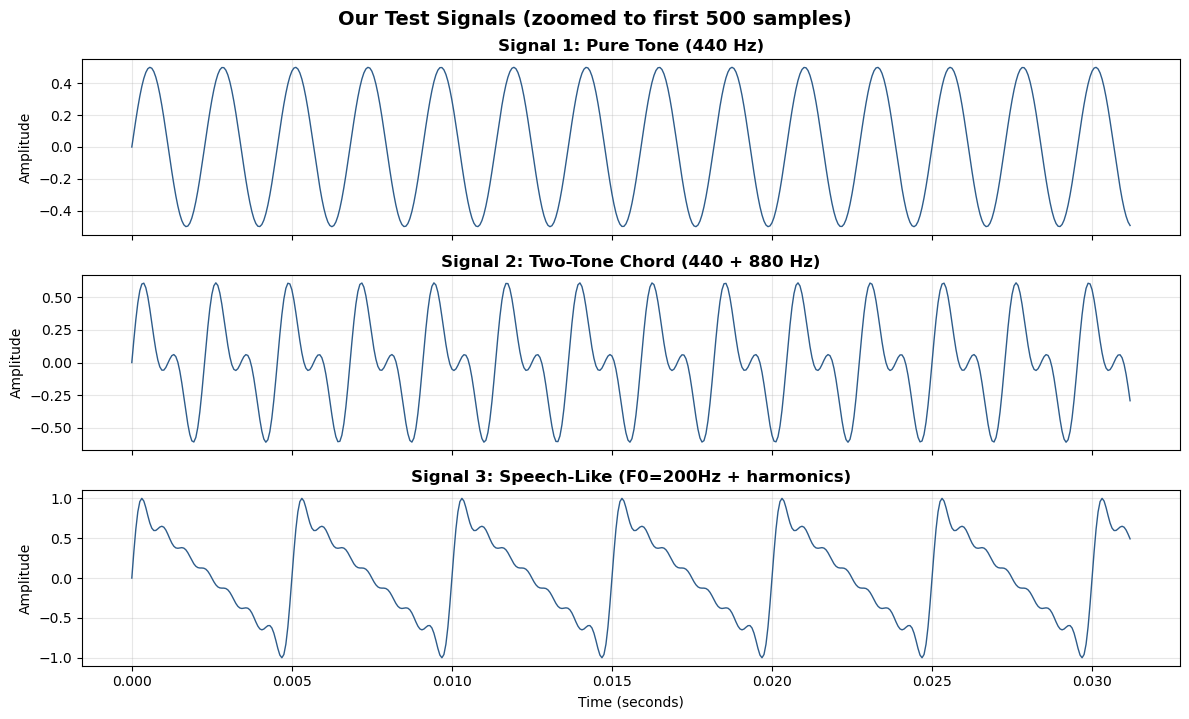

Sample rate: 16000 Hz
Duration: 1.0 s
Total samples: 16000


In [9]:
#  SIGNAL PARAMETERS
SAMPLE_RATE = 16000   # 16 kHz  (common for speech), this means 16000 samples per second
DURATION    = 1.0     # 1 second
t = np.linspace(0, DURATION, int(SAMPLE_RATE * DURATION), endpoint=False)

print(t.shape)
print(len(t))

#  SIGNAL 1: Pure Tone (440 Hz = musical note A4)
pure_tone = 0.5 * np.sin(2 * np.pi * 440 * t)

#  SIGNAL 2: Two-Tone Chord (440 Hz + 880 Hz)
two_tone = 0.4 * np.sin(2 * np.pi * 440 * t) + \
           0.3 * np.sin(2 * np.pi * 880 * t)

#  SIGNAL 3: Speech-Like Signal
#  A human voice has: fundamental freq (F0) + harmonics
#  We simulate a voice with F0=200Hz + harmonics that decay
F0 = 200  # Fundamental frequency (typical male voice)
speech_like = np.zeros_like(t)
for harmonic_num in range(1, 8):  # 7 harmonics
    amplitude = 1.0 / harmonic_num   # harmonics get quieter
    freq = F0 * harmonic_num          # 200, 400, 600, 800...
    speech_like += amplitude * np.sin(2 * np.pi * freq * t)
speech_like /= np.max(np.abs(speech_like))  # normalize to [-1, 1]

#  PLOT ALL THREE SIGNALS
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

signals = {
    'Signal 1: Pure Tone (440 Hz)': pure_tone,
    'Signal 2: Two-Tone Chord (440 + 880 Hz)': two_tone,
    'Signal 3: Speech-Like (F0=200Hz + harmonics)': speech_like
}

for ax, (name, sig) in zip(axes, signals.items()):
    ax.plot(t[:500], sig[:500], color='#2E5C8A', linewidth=1)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.suptitle('Our Test Signals (zoomed to first 500 samples)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print(f'Sample rate: {SAMPLE_RATE} Hz')
print(f'Duration: {DURATION} s')
print(f'Total samples: {len(t)}')

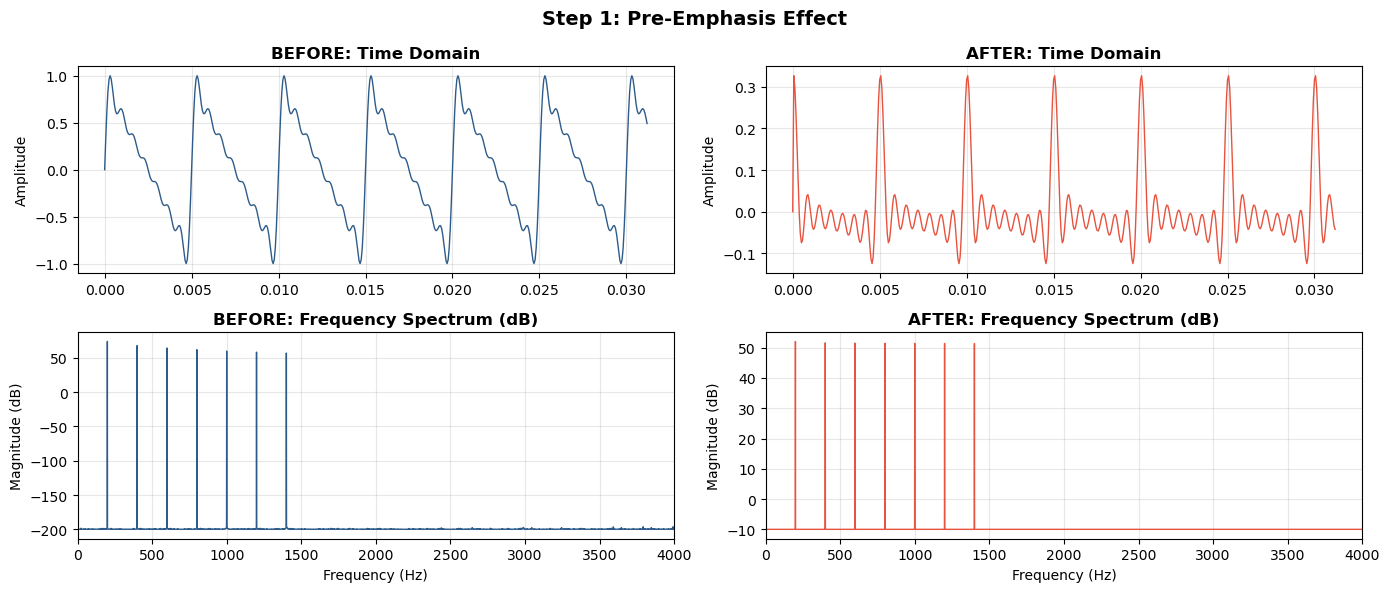

Notice: In the AFTER spectrum, high-frequency peaks are BOOSTED
The spectrum is now more balanced — easier to extract features from


In [14]:
def pre_emphasis(signal, alpha=0.97):
    """
    Apply pre-emphasis filter to boost high frequencies.
    y[n] = x[n] - alpha * x[n-1]
    """
    emphasized = np.zeros_like(signal)
    emphasized[0] = signal[0]          # first sample stays the same
    for n in range(1, len(signal)):
        emphasized[n] = signal[n] - alpha * signal[n-1]  # apply filter
    return emphasized

# Apply to our speech-like signal
speech_emphasized = pre_emphasis(speech_like, alpha=0.97)

#  PLOT: Before vs After Pre-Emphasis
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

# Time domain
axes[0, 0].plot(t[:500], speech_like[:500], color='#2E5C8A', linewidth=1)
axes[0, 0].set_title('BEFORE: Time Domain', fontweight='bold')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t[:500], speech_emphasized[:500], color='#E8533F', linewidth=1)
axes[0, 1].set_title('AFTER: Time Domain', fontweight='bold')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

# Frequency domain (FFT)
N = len(speech_like)
freqs = np.fft.fftfreq(N, 1/SAMPLE_RATE)[:N//2]

spec_before = np.abs(np.fft.fft(speech_like))[:N//2]
spec_after  = np.abs(np.fft.fft(speech_emphasized))[:N//2]

axes[1, 0].plot(freqs, 20*np.log10(spec_before + 1e-10), color='#2E5C8A', linewidth=1)
axes[1, 0].set_title('BEFORE: Frequency Spectrum (dB)', fontweight='bold')
axes[1, 0].set_ylabel('Magnitude (dB)')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_xlim([0, 4000])
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(freqs, 20*np.log10(spec_after + 1e-10), color='#E8533F', linewidth=1)
axes[1, 1].set_title('AFTER: Frequency Spectrum (dB)', fontweight='bold')
axes[1, 1].set_ylabel('Magnitude (dB)')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_xlim([0, 4000])
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Step 1: Pre-Emphasis Effect', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Notice: In the AFTER spectrum, high-frequency peaks are BOOSTED')
print('The spectrum is now more balanced — easier to extract features from')

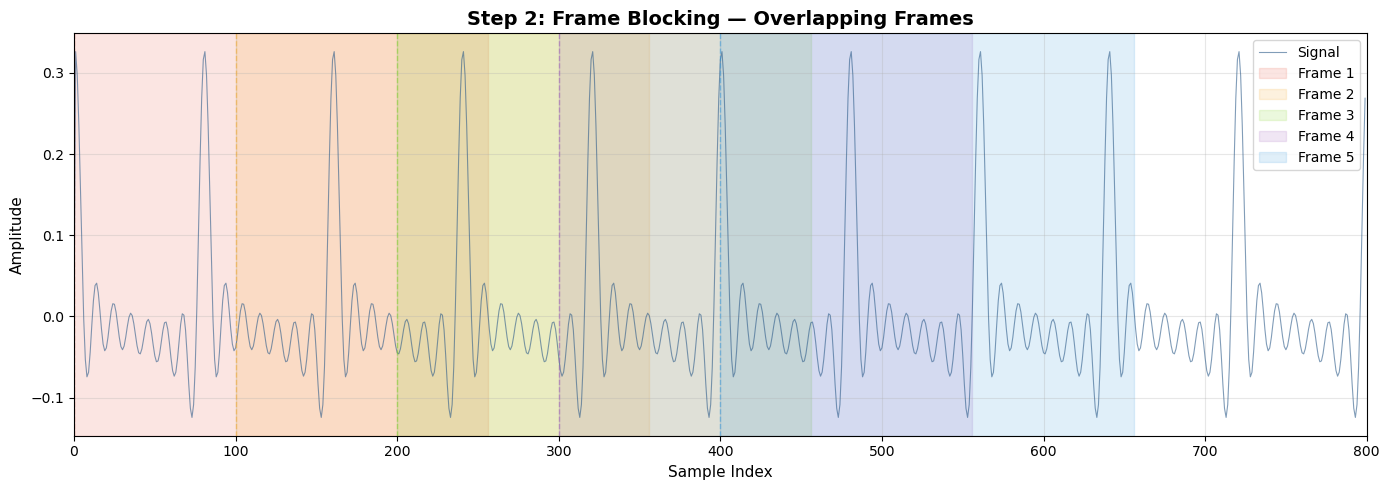

Frame length : 256 samples (16.0 ms)
Frame shift  : 100 samples (6.2 ms)
Overlap      : 156 samples
Total frames : 158
Frames shape : (158, 256)  →  (num_frames × frame_length)


In [15]:
def frame_signal(signal, frame_length=256, frame_shift=100):
    """Divide signal into overlapping frames. Returns: 2D array where each ROW is one frame"""
    num_frames = 1 + (len(signal) - frame_length) // frame_shift
    frames = np.zeros((num_frames, frame_length))
    
    for i in range(num_frames):
        start = i * frame_shift
        end   = start + frame_length
        frames[i] = signal[start:end]
    
    return frames

# Frame our emphasized signal
FRAME_LENGTH = 256   # 16ms at 16kHz
FRAME_SHIFT  = 100   # ~6.25ms shift

frames = frame_signal(speech_emphasized, FRAME_LENGTH, FRAME_SHIFT)

#  PLOT: Show how frames overlap
fig, ax = plt.subplots(figsize=(14, 5))

# Plot the signal
ax.plot(speech_emphasized[:800], color='#2E5C8A', linewidth=0.8, alpha=0.6, label='Signal')

# Highlight first 5 frames with different colors
colors = ['#E8533F', '#F5A623', '#7ED321', '#9B59B6', '#3498DB']
for i in range(5):
    start = i * FRAME_SHIFT
    end   = start + FRAME_LENGTH
    ax.axvspan(start, end, alpha=0.15, color=colors[i], label=f'Frame {i+1}')
    ax.axvline(x=start, color=colors[i], linestyle='--', alpha=0.5, linewidth=1)

ax.set_xlabel('Sample Index', fontsize=11)
ax.set_ylabel('Amplitude', fontsize=11)
ax.set_title('Step 2: Frame Blocking — Overlapping Frames', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 800])
plt.tight_layout()
plt.show()

print(f'Frame length : {FRAME_LENGTH} samples ({FRAME_LENGTH/SAMPLE_RATE*1000:.1f} ms)')
print(f'Frame shift  : {FRAME_SHIFT} samples ({FRAME_SHIFT/SAMPLE_RATE*1000:.1f} ms)')
print(f'Overlap      : {FRAME_LENGTH - FRAME_SHIFT} samples')
print(f'Total frames : {frames.shape[0]}')
print(f'Frames shape : {frames.shape}  →  (num_frames × frame_length)')

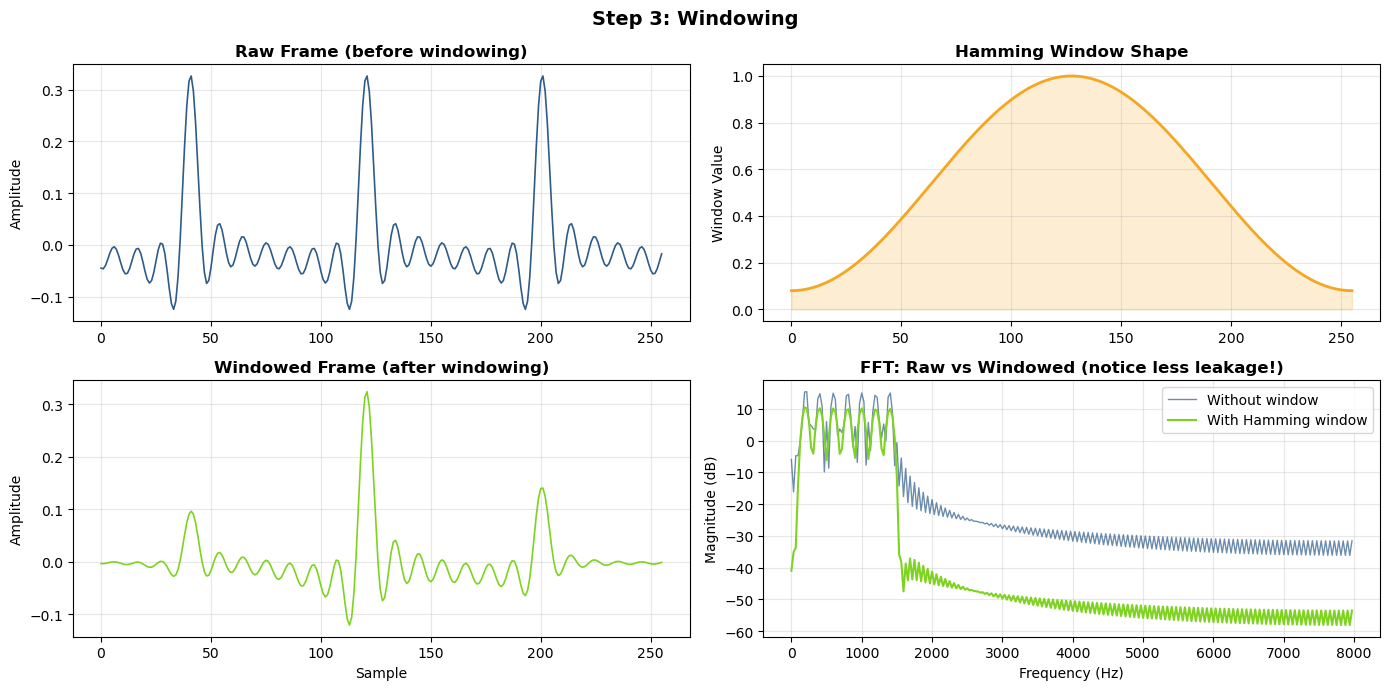

The windowed frame tapers smoothly to zero at the edges
This reduces spectral leakage in the FFT!


In [16]:
def apply_window(frames):
    """Apply Hamming window to each frame."""
    frame_length = frames.shape[1]
    hamming = np.hamming(frame_length)   # built-in Hamming window
    windowed = frames * hamming          # multiply each frame by window
    return windowed, hamming

windowed_frames, hamming_window = apply_window(frames)


#  PLOT: Window effect on one frame
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

frame_idx = 10  # pick a frame to visualize
n = np.arange(FRAME_LENGTH)

# Raw frame
axes[0, 0].plot(n, frames[frame_idx], color='#2E5C8A', linewidth=1.2)
axes[0, 0].set_title('Raw Frame (before windowing)', fontweight='bold')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

# Hamming window shape
axes[0, 1].plot(n, hamming_window, color='#F5A623', linewidth=2)
axes[0, 1].fill_between(n, hamming_window, alpha=0.2, color='#F5A623')
axes[0, 1].set_title('Hamming Window Shape', fontweight='bold')
axes[0, 1].set_ylabel('Window Value')
axes[0, 1].grid(True, alpha=0.3)

# Windowed frame
axes[1, 0].plot(n, windowed_frames[frame_idx], color='#7ED321', linewidth=1.2)
axes[1, 0].set_title('Windowed Frame (after windowing)', fontweight='bold')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].set_xlabel('Sample')
axes[1, 0].grid(True, alpha=0.3)

# FFT comparison: raw vs windowed
fft_raw = np.abs(np.fft.fft(frames[frame_idx], n=512))[:256]
fft_win = np.abs(np.fft.fft(windowed_frames[frame_idx], n=512))[:256]
freq_axis = np.fft.fftfreq(512, 1/SAMPLE_RATE)[:256]

axes[1, 1].plot(freq_axis, 20*np.log10(fft_raw + 1e-10), color='#2E5C8A', linewidth=1, label='Without window', alpha=0.7)
axes[1, 1].plot(freq_axis, 20*np.log10(fft_win + 1e-10), color='#7ED321', linewidth=1.5, label='With Hamming window')
axes[1, 1].set_title('FFT: Raw vs Windowed (notice less leakage!)', fontweight='bold')
axes[1, 1].set_ylabel('Magnitude (dB)')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Step 3: Windowing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('The windowed frame tapers smoothly to zero at the edges')
print('This reduces spectral leakage in the FFT!')

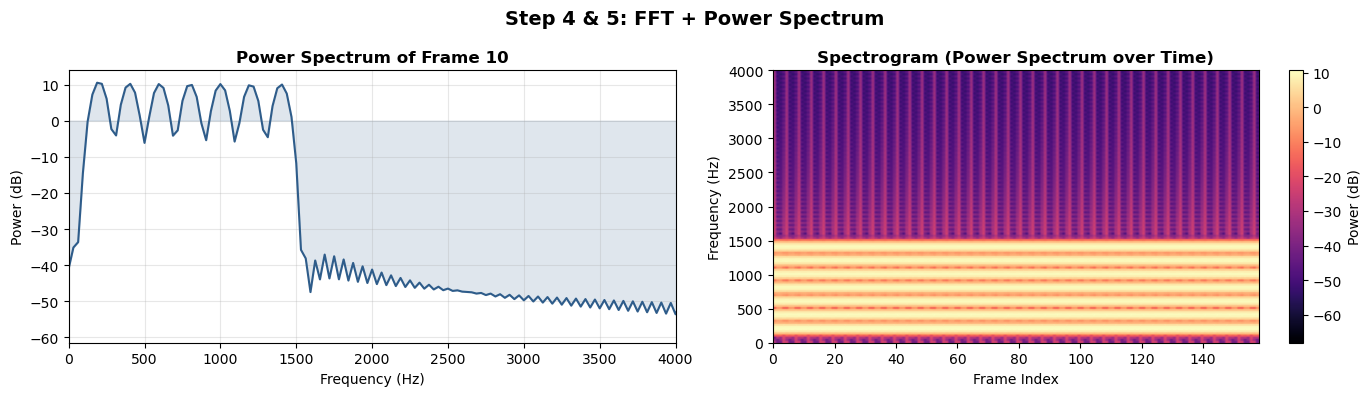

Power spectrum shape: (158, 257)
158 frames × 257 frequency bins
Each column in the spectrogram = one frame's power spectrum
You can see the harmonic structure (horizontal lines = harmonics)


In [18]:
def compute_power_spectrum(windowed_frames, n_fft=512):
    """
    Compute power spectrum for each frame.
    n_fft: FFT size (zero-pads if frame is shorter)
    Returns: power spectrum (only positive frequencies)
    """
    num_frames = windowed_frames.shape[0]
    n_positive = n_fft // 2 + 1   # only positive frequencies
    power_spec = np.zeros((num_frames, n_positive))
    
    for i in range(num_frames):
        fft_result = np.fft.fft(windowed_frames[i], n=n_fft)  # compute FFT
        power_spec[i] = np.abs(fft_result[:n_positive]) ** 2  # |FFT|²
    
    return power_spec

N_FFT = 512
power_spectrum = compute_power_spectrum(windowed_frames, n_fft=N_FFT)

# Frequency axis
freq_axis = np.linspace(0, SAMPLE_RATE / 2, N_FFT // 2 + 1)

#  PLOT: Power spectrum of a single frame + spectrogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Single frame power spectrum
axes[0].plot(freq_axis, 10*np.log10(power_spectrum[frame_idx] + 1e-10), color='#2E5C8A', linewidth=1.5)
axes[0].fill_between(freq_axis, 10*np.log10(power_spectrum[frame_idx] + 1e-10), alpha=0.15, color='#2E5C8A')
axes[0].set_title(f'Power Spectrum of Frame {frame_idx}', fontweight='bold')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power (dB)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 4000])

# Spectrogram (all frames stacked)
im = axes[1].imshow(
    10*np.log10(power_spectrum.T + 1e-10),
    aspect='auto',
    origin='lower',
    cmap='magma',
    extent=[0, power_spectrum.shape[0], 0, SAMPLE_RATE/2]
)
axes[1].set_title('Spectrogram (Power Spectrum over Time)', fontweight='bold')
axes[1].set_xlabel('Frame Index')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim([0, 4000])
plt.colorbar(im, ax=axes[1], label='Power (dB)')

plt.suptitle('Step 4 & 5: FFT + Power Spectrum', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Power spectrum shape: {power_spectrum.shape}')
print(f'{power_spectrum.shape[0]} frames × {power_spectrum.shape[1]} frequency bins')
print(f'Each column in the spectrogram = one frame\'s power spectrum')
print(f'You can see the harmonic structure (horizontal lines = harmonics)')

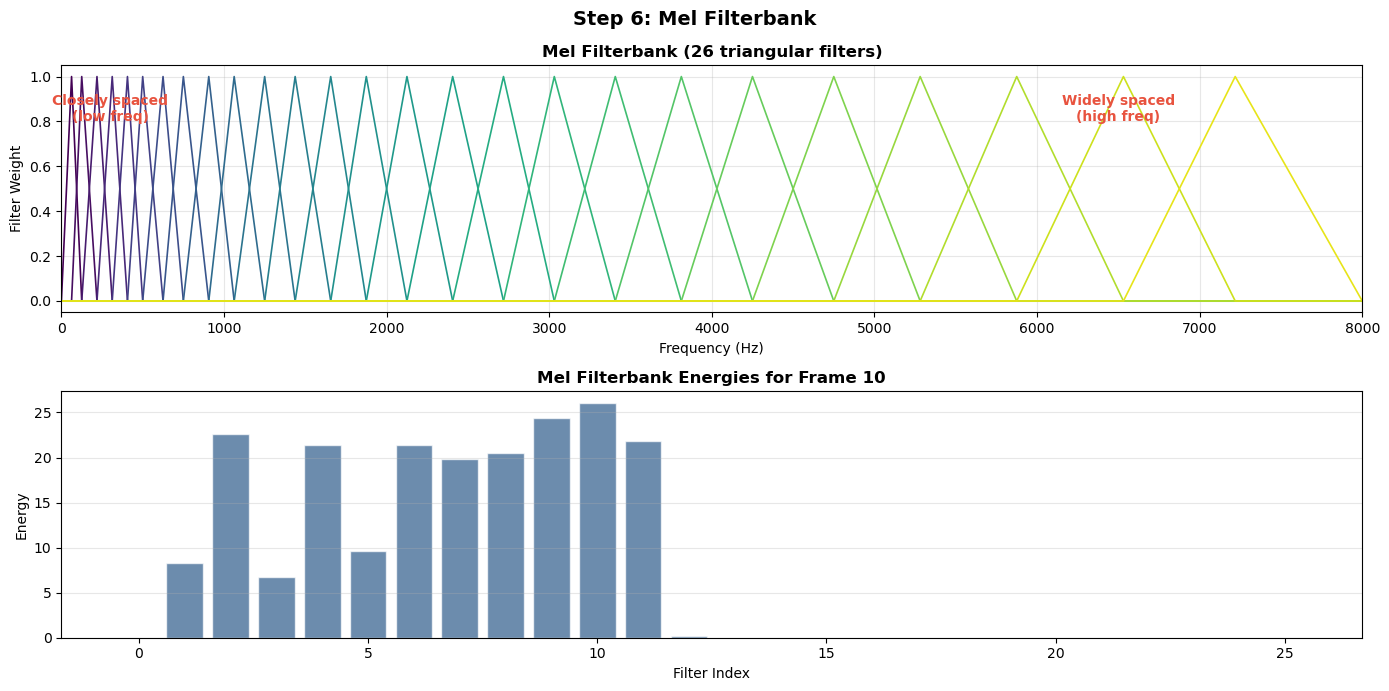

Filterbank shape: (26, 257)  →  (26 filters × 257 freq bins)
Notice: filters are NARROW at low freq, WIDE at high freq
This matches how human ears perceive sound


In [19]:
def hz_to_mel(f):
    """Convert Hz to Mel scale."""
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    """Convert Mel scale back to Hz."""
    return 700 * (10 ** (m / 2595) - 1)

def create_mel_filterbank(n_filters=26, n_fft=512, sample_rate=16000, f_min=0, f_max=None):
    """
    Create a bank of triangular Mel-scaled filters.
    n_filters: number of triangular filters
    Returns: filterbank matrix of shape (n_filters × n_fft//2+1)
    """
    if f_max is None:
        f_max = sample_rate / 2  # Nyquist
    
    n_positive = n_fft // 2 + 1
    
    # Step 1: Create equally spaced points on MEL scale
    mel_min = hz_to_mel(f_min)
    mel_max = hz_to_mel(f_max)
    mel_points = np.linspace(mel_min, mel_max, n_filters + 2)  # +2 for edges
    
    # Step 2: Convert back to Hz
    hz_points = mel_to_hz(mel_points)
    
    # Step 3: Map to FFT bin indices
    bin_points = np.floor((n_fft + 1) * hz_points / sample_rate).astype(int)
    
    # Step 4: Build triangular filters
    filterbank = np.zeros((n_filters, n_positive))
    
    for i in range(n_filters):
        left   = bin_points[i]       # left edge
        center = bin_points[i + 1]   # center (peak)
        right  = bin_points[i + 2]   # right edge
        
        # Rising slope: left → center
        for k in range(left, center):
            if center != left:
                filterbank[i, k] = (k - left) / (center - left)
        
        # Falling slope: center → right
        for k in range(center, right):
            if right != center:
                filterbank[i, k] = (right - k) / (right - center)
    
    return filterbank, hz_points

# Create filterbank
N_FILTERS = 26
filterbank, hz_points = create_mel_filterbank(n_filters=N_FILTERS, n_fft=N_FFT, sample_rate=SAMPLE_RATE)

#  PLOT: The Mel Filterbank
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Plot filterbank
for i in range(N_FILTERS):
    axes[0].plot(freq_axis, filterbank[i], color=plt.cm.viridis(i / N_FILTERS), linewidth=1.2)

axes[0].set_title(f'Mel Filterbank ({N_FILTERS} triangular filters)', fontweight='bold')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Filter Weight')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, SAMPLE_RATE/2])

# Annotate spacing
axes[0].annotate('Closely spaced\n(low freq)', xy=(300, 0.8), fontsize=10, 
                color='#E8533F', fontweight='bold', ha='center')
axes[0].annotate('Widely spaced\n(high freq)', xy=(6500, 0.8), fontsize=10,
                color='#E8533F', fontweight='bold', ha='center')

# Apply filterbank to power spectrum of one frame
mel_energies_single = filterbank @ power_spectrum[frame_idx]  # matrix multiply!

axes[1].bar(range(N_FILTERS), mel_energies_single, color='#2E5C8A', alpha=0.7, edgecolor='white')
axes[1].set_title(f'Mel Filterbank Energies for Frame {frame_idx}', fontweight='bold')
axes[1].set_xlabel('Filter Index')
axes[1].set_ylabel('Energy')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Step 6: Mel Filterbank', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Filterbank shape: {filterbank.shape}  →  ({N_FILTERS} filters × {N_FFT//2+1} freq bins)')
print(f'Notice: filters are NARROW at low freq, WIDE at high freq')
print(f'This matches how human ears perceive sound')

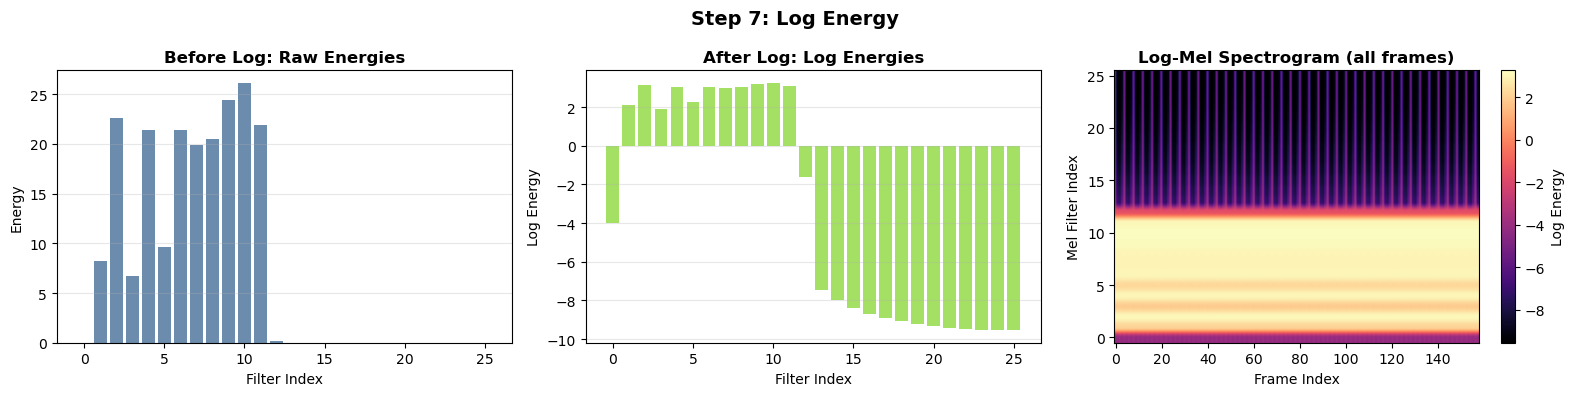

Log compresses large differences into smaller ones
Raw energy range:  [0.00, 26.35]
Log energy range:  [-9.55, 3.27]


In [20]:
def apply_log(mel_energies, eps=1e-10):
    """
    Apply log to mel filterbank energies.
    eps prevents log(0) which would be -infinity.
    """
    return np.log(mel_energies + eps)

# Apply filterbank to ALL frames → then log
mel_energies_all = filterbank @ power_spectrum.T   # shape: (n_filters × n_frames)
log_mel_energies = apply_log(mel_energies_all)     # take log

#  PLOT: Before log vs After log
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Before log (single frame)
axes[0].bar(range(N_FILTERS), mel_energies_all[:, frame_idx], color='#2E5C8A', alpha=0.7)
axes[0].set_title('Before Log: Raw Energies', fontweight='bold')
axes[0].set_xlabel('Filter Index')
axes[0].set_ylabel('Energy')
axes[0].grid(True, alpha=0.3, axis='y')

# After log (single frame)
axes[1].bar(range(N_FILTERS), log_mel_energies[:, frame_idx], color='#7ED321', alpha=0.7)
axes[1].set_title('After Log: Log Energies', fontweight='bold')
axes[1].set_xlabel('Filter Index')
axes[1].set_ylabel('Log Energy')
axes[1].grid(True, alpha=0.3, axis='y')

# Log-Mel spectrogram (all frames)
im = axes[2].imshow(
    log_mel_energies,
    aspect='auto',
    origin='lower',
    cmap='magma'
)
axes[2].set_title('Log-Mel Spectrogram (all frames)', fontweight='bold')
axes[2].set_xlabel('Frame Index')
axes[2].set_ylabel('Mel Filter Index')
plt.colorbar(im, ax=axes[2], label='Log Energy')

plt.suptitle('Step 7: Log Energy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Log compresses large differences into smaller ones')
print(f'Raw energy range:  [{mel_energies_all.min():.2f}, {mel_energies_all.max():.2f}]')
print(f'Log energy range:  [{log_mel_energies.min():.2f}, {log_mel_energies.max():.2f}]')

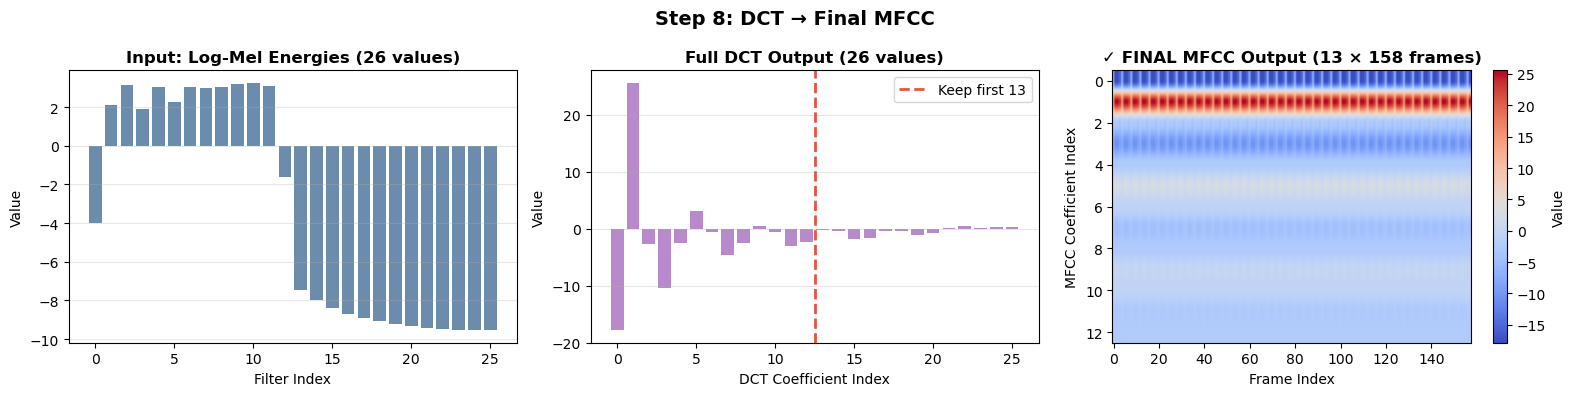

MFCC shape: (13, 158)  →  (13 coefficients × 158 frames)
After DCT, most energy is in the first few coefficients
We keep 13 — that's enough to capture the spectral shape!


In [21]:
def apply_dct(log_mel_energies, n_mfcc=13):
    """
    Apply DCT and keep first n_mfcc coefficients.
    scipy.fftpack.dct with type=2 is the standard DCT-II.
    """
    # Apply DCT along axis=0 (across filters for each frame)
    dct_result = dct(log_mel_energies, type=2, axis=0, norm='ortho')
    
    # Keep only first n_mfcc coefficients
    mfcc = dct_result[:n_mfcc, :]
    
    return mfcc

N_MFCC = 13
mfcc_result = apply_dct(log_mel_energies, n_mfcc=N_MFCC)

#  PLOT: DCT effect + Final MFCC
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Log-mel energies (single frame)
axes[0].bar(range(N_FILTERS), log_mel_energies[:, frame_idx], color='#2E5C8A', alpha=0.7)
axes[0].set_title('Input: Log-Mel Energies (26 values)', fontweight='bold')
axes[0].set_xlabel('Filter Index')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3, axis='y')

# Full DCT output
full_dct = dct(log_mel_energies[:, frame_idx], type=2, norm='ortho')
axes[1].bar(range(len(full_dct)), full_dct, color='#9B59B6', alpha=0.7)
axes[1].axvline(x=N_MFCC - 0.5, color='#E8533F', linestyle='--', linewidth=2, label=f'Keep first {N_MFCC}')
axes[1].set_title('Full DCT Output (26 values)', fontweight='bold')
axes[1].set_xlabel('DCT Coefficient Index')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Final MFCC heatmap
im = axes[2].imshow(
    mfcc_result,
    aspect='auto',
    origin='upper',
    cmap='coolwarm'
)
axes[2].set_title(f'✓ FINAL MFCC Output ({N_MFCC} × {mfcc_result.shape[1]} frames)', fontweight='bold')
axes[2].set_xlabel('Frame Index')
axes[2].set_ylabel('MFCC Coefficient Index')
plt.colorbar(im, ax=axes[2], label='Value')

plt.suptitle('Step 8: DCT → Final MFCC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'MFCC shape: {mfcc_result.shape}  →  ({N_MFCC} coefficients × {mfcc_result.shape[1]} frames)')
print(f'After DCT, most energy is in the first few coefficients')
print(f'We keep 13 — that\'s enough to capture the spectral shape!')

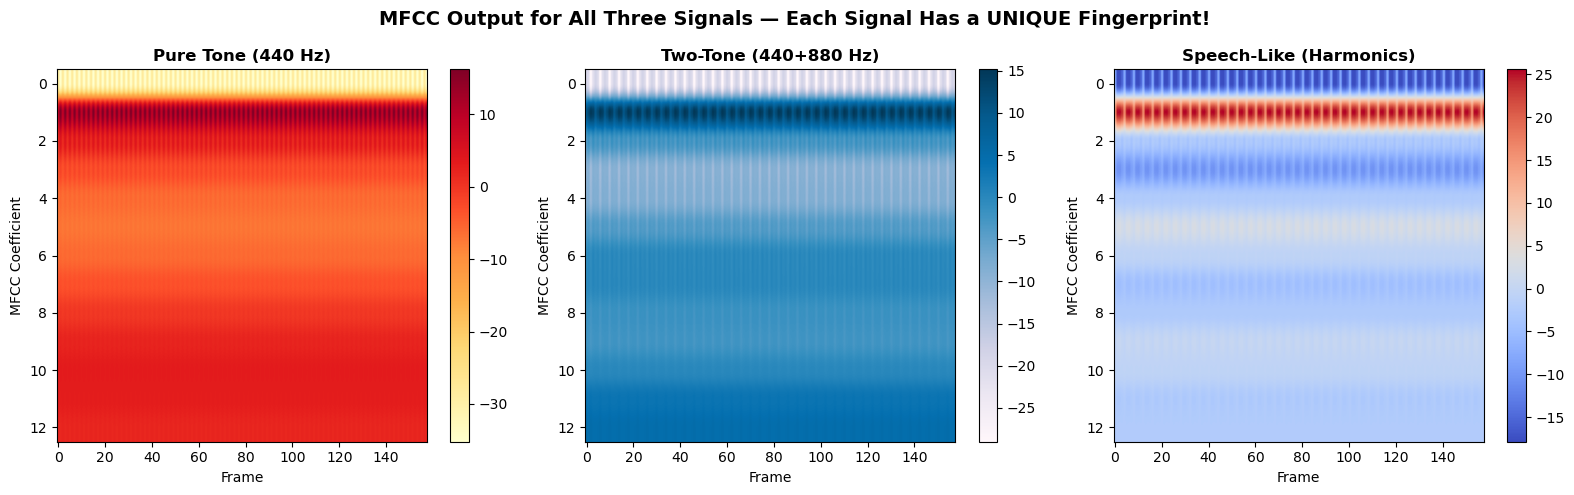

Each signal produces a DIFFERENT MFCC pattern!
This is exactly how speaker recognition works:
different voices → different MFCC patterns


In [22]:
def compute_mfcc(signal, sample_rate=16000, n_fft=512, frame_length=256,
                 frame_shift=100, n_filters=26, n_mfcc=13, alpha=0.97):
    """
    Complete MFCC computation from raw audio signal.
    
    Parameters:
        signal       : 1D numpy array (raw audio)
        sample_rate  : sampling frequency in Hz
        n_fft        : FFT size
        frame_length : length of each frame in samples
        frame_shift  : shift between frames in samples
        n_filters    : number of mel filterbank filters
        n_mfcc       : number of MFCC coefficients to keep
        alpha        : pre-emphasis coefficient
    
    Returns:
        mfcc : array of shape (n_mfcc × num_frames)
    """
    # Step 1: Pre-emphasis
    emphasized = pre_emphasis(signal, alpha)
    
    # Step 2: Frame blocking
    frames = frame_signal(emphasized, frame_length, frame_shift)
    
    # Step 3: Windowing
    windowed, _ = apply_window(frames)
    
    # Step 4 & 5: FFT + Power Spectrum
    power_spec = compute_power_spectrum(windowed, n_fft)
    
    # Step 6: Mel Filterbank
    fb, _ = create_mel_filterbank(n_filters, n_fft, sample_rate)
    mel_energies = fb @ power_spec.T   # (n_filters × num_frames)
    
    # Step 7: Log
    log_energies = apply_log(mel_energies)
    
    # Step 8: DCT
    mfcc = apply_dct(log_energies, n_mfcc)
    
    return mfcc

#  Run on ALL three signals
mfcc_pure  = compute_mfcc(pure_tone, SAMPLE_RATE)
mfcc_two   = compute_mfcc(two_tone, SAMPLE_RATE)
mfcc_speech = compute_mfcc(speech_like, SAMPLE_RATE)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, mfcc, title, cmap in zip(
    axes,
    [mfcc_pure, mfcc_two, mfcc_speech],
    ['Pure Tone (440 Hz)', 'Two-Tone (440+880 Hz)', 'Speech-Like (Harmonics)'],
    ['YlOrRd', 'PuBu', 'coolwarm']
):
    im = ax.imshow(mfcc, aspect='auto', origin='upper', cmap=cmap)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Frame')
    ax.set_ylabel('MFCC Coefficient')
    plt.colorbar(im, ax=ax)

plt.suptitle('MFCC Output for All Three Signals — Each Signal Has a UNIQUE Fingerprint!',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Each signal produces a DIFFERENT MFCC pattern!')
print('This is exactly how speaker recognition works:')
print('different voices → different MFCC patterns')

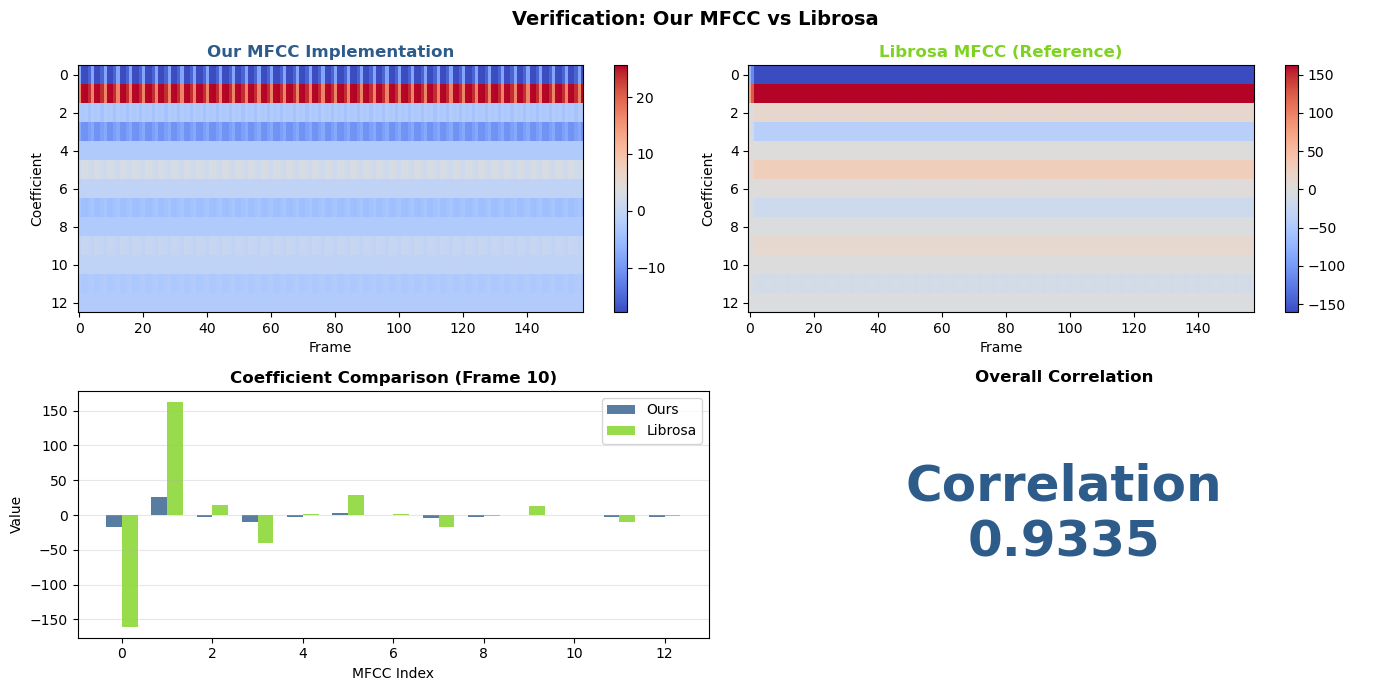

Overall correlation: 0.9335

Good correlation! Small differences are normal because:
  Librosa uses slightly different filterbank spacing
  Librosa applies pre-emphasis differently
  Edge handling in framing may differ
  The PATTERN and SHAPE should match even if values differ slightly


In [25]:
# Librosa's MFCC (reference implementation)
mfcc_librosa = librosa.feature.mfcc(
    y=speech_like.astype(np.float32),
    sr=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    n_fft=N_FFT,
    hop_length=FRAME_SHIFT,
    win_length=FRAME_LENGTH,
    n_mels=N_FILTERS
)

# Our MFCC
mfcc_ours = compute_mfcc(speech_like, SAMPLE_RATE)

# Match frame counts
min_frames = min(mfcc_ours.shape[1], mfcc_librosa.shape[1])

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Our MFCC
im1 = axes[0, 0].imshow(mfcc_ours[:, :min_frames], aspect='auto', origin='upper', cmap='coolwarm')
axes[0, 0].set_title('Our MFCC Implementation', fontweight='bold', color='#2E5C8A')
axes[0, 0].set_xlabel('Frame')
axes[0, 0].set_ylabel('Coefficient')
plt.colorbar(im1, ax=axes[0, 0])

# Librosa MFCC
im2 = axes[0, 1].imshow(mfcc_librosa[:, :min_frames], aspect='auto', origin='upper', cmap='coolwarm')
axes[0, 1].set_title('Librosa MFCC (Reference)', fontweight='bold', color='#7ED321')
axes[0, 1].set_xlabel('Frame')
axes[0, 1].set_ylabel('Coefficient')
plt.colorbar(im2, ax=axes[0, 1])

# Coefficient comparison (frame 10)
comp_frame = min(10, min_frames - 1)
x = np.arange(N_MFCC)
width = 0.35

axes[1, 0].bar(x - width/2, mfcc_ours[:, comp_frame], width, label='Ours', color='#2E5C8A', alpha=0.8)
axes[1, 0].bar(x + width/2, mfcc_librosa[:, comp_frame], width, label='Librosa', color='#7ED321', alpha=0.8)
axes[1, 0].set_title(f'Coefficient Comparison (Frame {comp_frame})', fontweight='bold')
axes[1, 0].set_xlabel('MFCC Index')
axes[1, 0].set_ylabel('Value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Correlation heatmap
corr_matrix = np.corrcoef(mfcc_ours[:, :min_frames].flatten(),
                           mfcc_librosa[:, :min_frames].flatten())
axes[1, 1].text(0.5, 0.5, f'Correlation\n{corr_matrix[0,1]:.4f}',
               ha='center', va='center', fontsize=36, fontweight='bold',
               color='#2E5C8A' if corr_matrix[0,1] > 0.8 else '#E8533F',
               transform=axes[1,1].transAxes)
axes[1, 1].set_title('Overall Correlation', fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle('Verification: Our MFCC vs Librosa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Overall correlation: {corr_matrix[0,1]:.4f}')
print()
if corr_matrix[0,1] > 0.8:
    print('Good correlation! Small differences are normal because:')
else:
    print('Check your implementation. Differences may be due to:')
print('  Librosa uses slightly different filterbank spacing')
print('  Librosa applies pre-emphasis differently')
print('  Edge handling in framing may differ')
print('  The PATTERN and SHAPE should match even if values differ slightly')

In [24]:
#  Example: Using librosa's built-in audio sample
try:
    # Load librosa's sample audio
    sample_audio, sample_sr = librosa.load(librosa.util.example_audio_file(), sr=16000)
    
    # Compute MFCC on real audio
    mfcc_real = compute_mfcc(sample_audio, sample_sr)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    
    # Waveform
    time_axis = np.linspace(0, len(sample_audio)/sample_sr, len(sample_audio))
    axes[0].plot(time_axis, sample_audio, color='#2E5C8A', linewidth=0.5)
    axes[0].set_title('Real Audio Waveform', fontweight='bold')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)
    
    # MFCC
    im = axes[1].imshow(mfcc_real, aspect='auto', origin='upper', cmap='magma')
    axes[1].set_title('MFCC of Real Audio — Notice the changing patterns over time!', fontweight='bold')
    axes[1].set_xlabel('Frame')
    axes[1].set_ylabel('MFCC Coefficient')
    plt.colorbar(im, ax=axes[1], label='Value')
    
    plt.tight_layout()
    plt.show()
    
    print(f'Real audio MFCC shape: {mfcc_real.shape}')
    print('MFCC patterns change over time → captures speech dynamics!')

except Exception as e:
    print(f'Could not load sample audio: {e}')
    print('Try loading your own .wav file instead!')

Could not load sample audio: No librosa.util attribute example_audio_file
Try loading your own .wav file instead!
